In [1]:
# Librerías para visión artificial
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Detección de la placa del auto

In [2]:
cv2.data.haarcascades

'/usr/local/lib/python3.12/dist-packages/cv2/data/'

In [3]:
ls '/usr/local/lib/python3.12/dist-packages/cv2/data/'

haarcascade_eye_tree_eyeglasses.xml
haarcascade_eye.xml
haarcascade_frontalcatface_extended.xml
haarcascade_frontalcatface.xml
haarcascade_frontalface_alt2.xml
haarcascade_frontalface_alt_tree.xml
haarcascade_frontalface_alt.xml
haarcascade_frontalface_default.xml
haarcascade_fullbody.xml
haarcascade_lefteye_2splits.xml
haarcascade_license_plate_rus_16stages.xml
haarcascade_lowerbody.xml
haarcascade_profileface.xml
haarcascade_righteye_2splits.xml
haarcascade_russian_plate_number.xml
haarcascade_smile.xml
haarcascade_upperbody.xml
__init__.py
__pycache__/


In [4]:
# Cargando el modelo preentrenado
plate_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml')

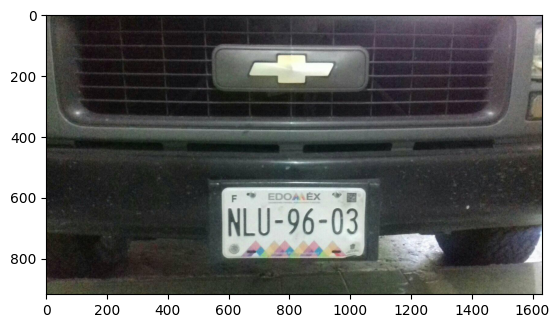

In [39]:
# Lectura de la imagen
img = cv2.imread("placa2.jpg")
# Conversión de formato
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [42]:
# Detección de placas
# scaleFactor es el % en el que se reduce la imagen en cada procesamiento 1.2=20%
#placas = plate_cascade.detectMultiScale(img, scaleFactor=1.2, minNeighbors=10)

placas = plate_cascade.detectMultiScale(img, scaleFactor = 1.1, minNeighbors = 1)
print(placas)

[[534 488 564 188]
 [552 576 564 188]]


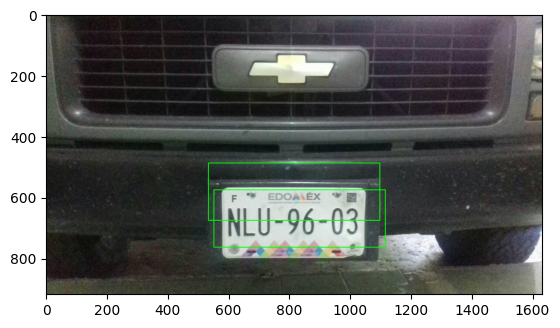

In [59]:
# Dibujo del cuadro delimitador de la placa
img_copy = np.copy(img)

for (x, y, w, h) in placas:
  cv2.rectangle(img_copy, (x,y), (x+w, y+h), (0, 255, 0), 2)

plt.imshow(img_copy, cmap = 'Accent')
plt.show()

## Extracción del texto

In [8]:
# Así instalamos líbrerias que no estan por default en Colaboratory
!pip install pytesseract
!sudo apt install tesseract-ocr
!sudo apt install libtesseract-dev
# Ejecutar esta línea y reiniciar el entorno sin volver a instalar las anteriores
!pip install Pillow==9.0.0

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libarchive-dev libleptonica-dev
The following NEW packages will be installed:
  libarchive-dev libleptonica-dev libtesseract-dev
0 upgraded, 3 newly installed, 0 to remove and 2 not upgraded.
Need to get 581 kB/3,743 kB of archives.
After this operation, 16.0 MB of additional disk space will be used.
Ign:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libarchive-dev amd64 3.6.0-1ubuntu1.5
Err:1 http://security.ubuntu.com/ubuntu jammy-updates/main amd64 libarchive-dev amd64 3.6.0-1ubuntu1.5
  404  Not Found [IP: 185.125.190.81 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/liba/libarchiv

In [9]:
# Librería para OCR
import pytesseract

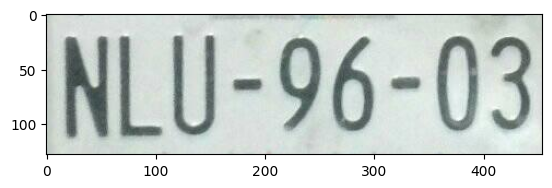

In [69]:
#placaRGB = img[y:y+h, x+30:x+w-70]
placaRGB = img[y+40:y+h-20, x+30:x+w-80]
plt.imshow(placaRGB, cmap = 'Accent')
plt.show()

Prueba 1: Imagen a color

In [70]:
textoRGB = pytesseract.image_to_string(placaRGB)
print(textoRGB)

NLU-96-03



Prueba 2: Imagen en escala de grises

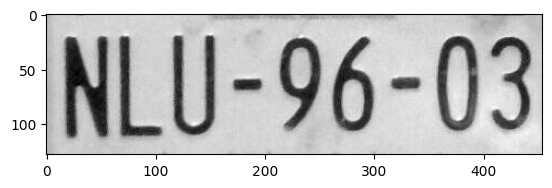

In [71]:
 # Convertimos a escala de grises
placaGray = cv2.cvtColor(placaRGB, cv2.COLOR_RGB2GRAY)

plt.imshow(placaGray, cmap='gray')
plt.show()

In [72]:
textoGray = pytesseract.image_to_string(placaGray)
print(textoGray)

NLU-96-03



Prueba 3: Imagen filtrada

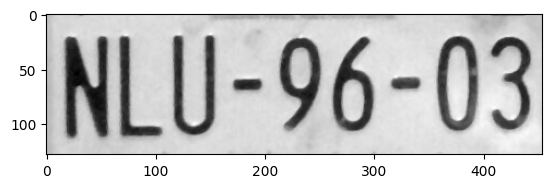

In [73]:
# Filtro de mediana sobre la imagen
placaFiltrada = cv2.medianBlur(placaGray, 3)

plt.imshow(placaFiltrada, cmap='gray')
plt.show()

In [74]:
textoFiltro = pytesseract.image_to_string(placaFiltrada)
print(textoFiltro)

NLU-96-03



Prueba 4: Imagen binarizada

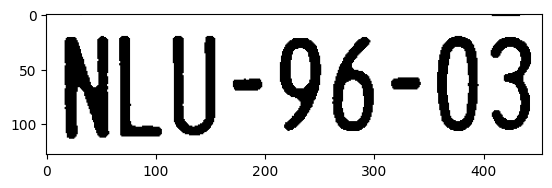

In [79]:
# Binarizado por medio de un límite
#ret, placaBin = cv2.threshold(placaFiltrada, thresh = 93, maxval = 255, type = cv2.THRESH_BINARY)
ret, placaBin = cv2.threshold(placaFiltrada, thresh = 177, maxval = 255, type = cv2.THRESH_BINARY)

plt.imshow(placaBin, cmap='gray')
plt.show()

In [77]:
textoBin = pytesseract.image_to_string(placaBin)
print(textoBin)

NLU-96-03



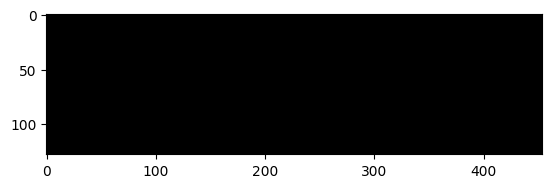

umbral: 0



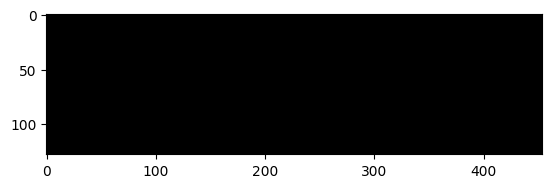

umbral: 1



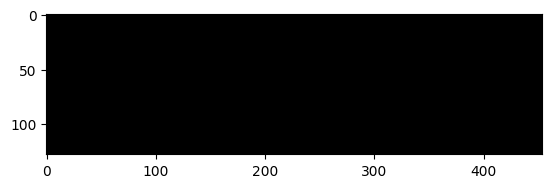

umbral: 2



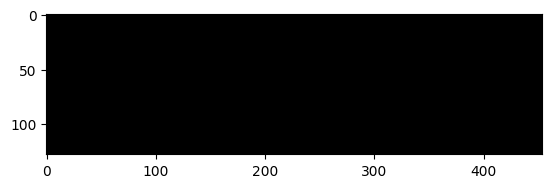

umbral: 3



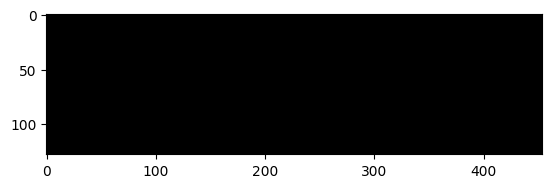

umbral: 4



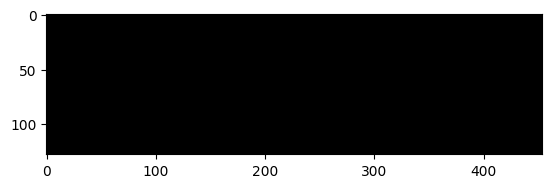

umbral: 5



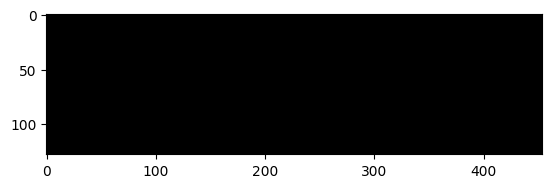

umbral: 6



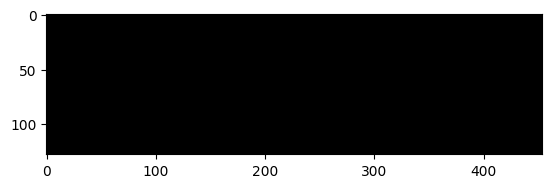

umbral: 7



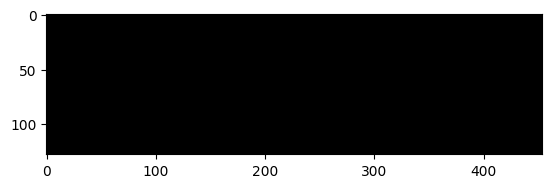

umbral: 8



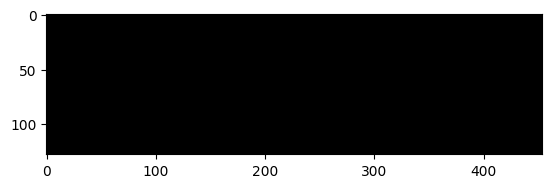

umbral: 9



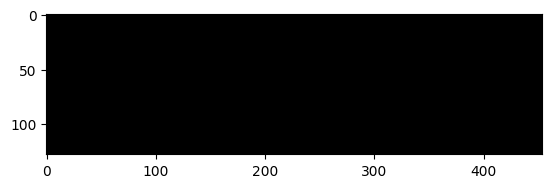

umbral: 10



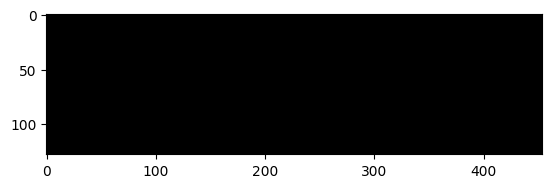

umbral: 11



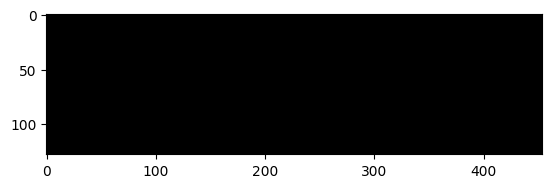

umbral: 12



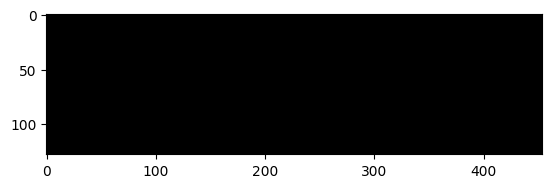

umbral: 13



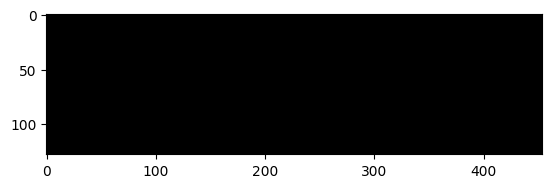

umbral: 14



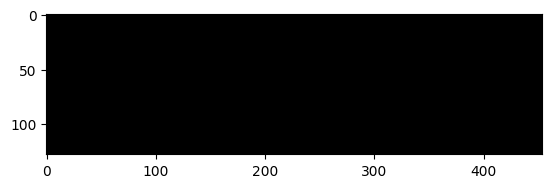

umbral: 15



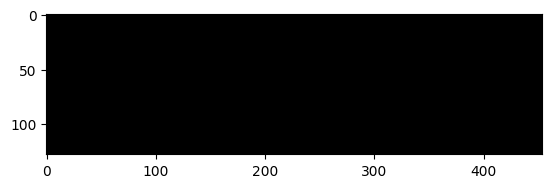

umbral: 16



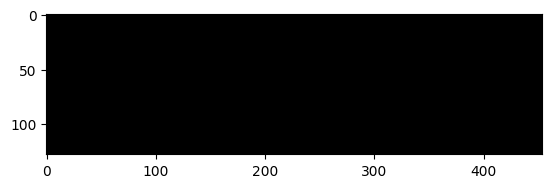

umbral: 17



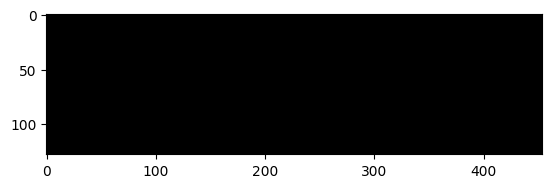

umbral: 18



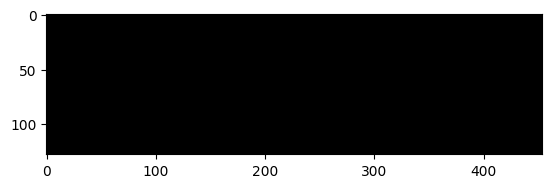

umbral: 19



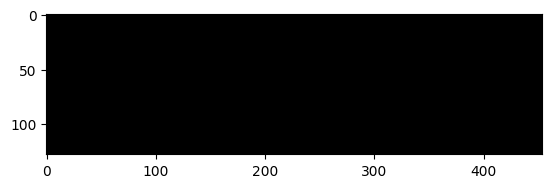

umbral: 20



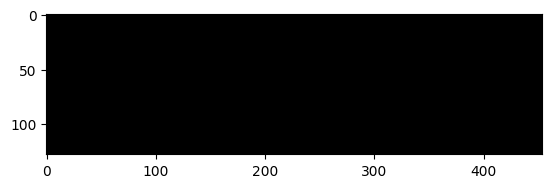

umbral: 21



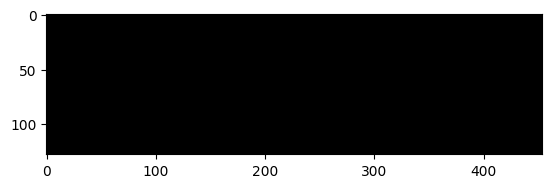

umbral: 22



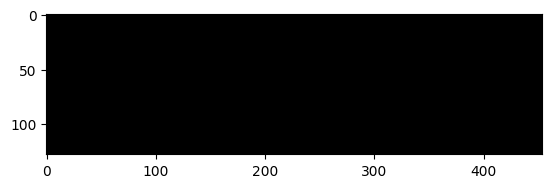

umbral: 23



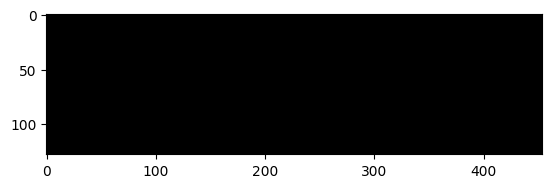

umbral: 24



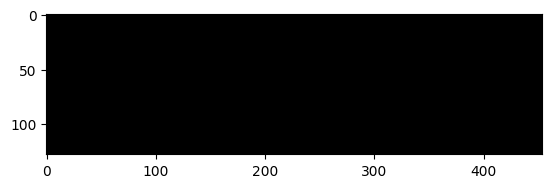

umbral: 25



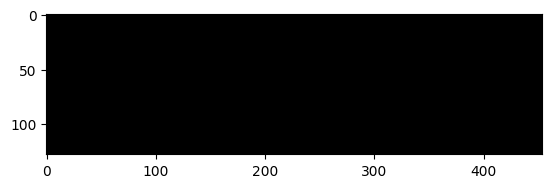

umbral: 26



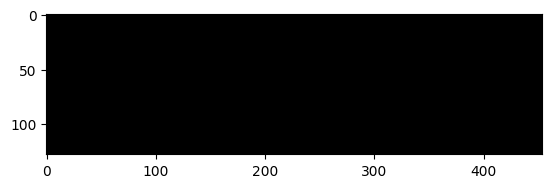

umbral: 27



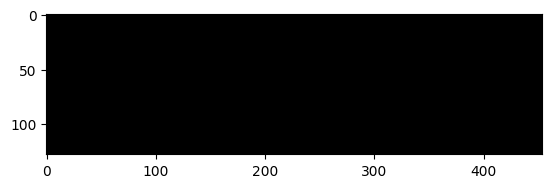

umbral: 28



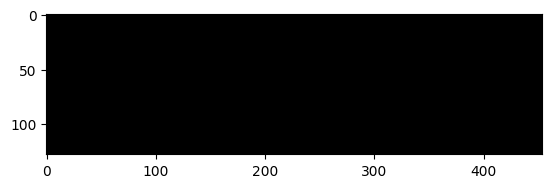

umbral: 29



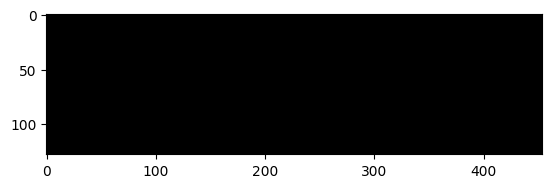

umbral: 30



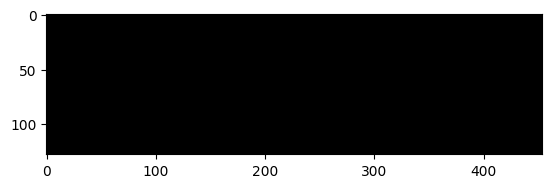

umbral: 31



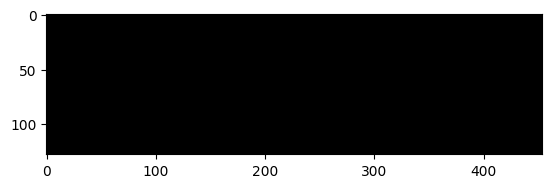

umbral: 32



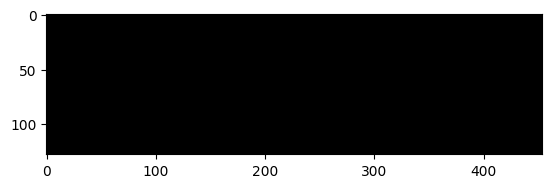

umbral: 33



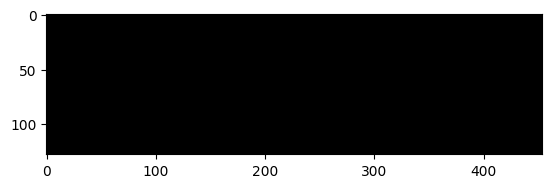

umbral: 34



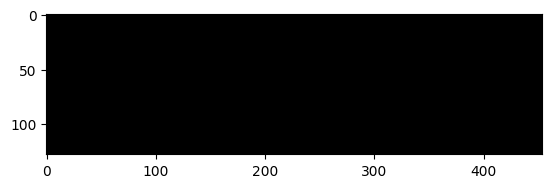

umbral: 35



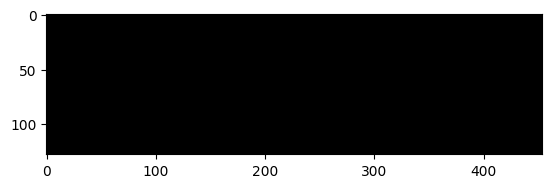

umbral: 36



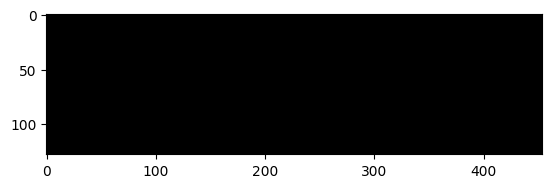

umbral: 37



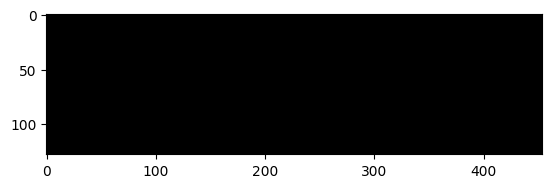

umbral: 38



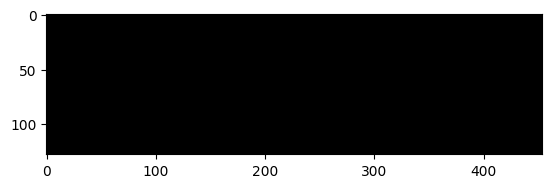

umbral: 39



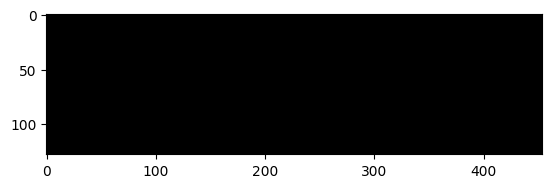

umbral: 40



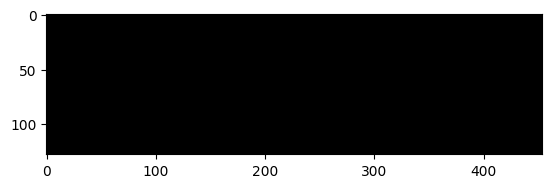

umbral: 41



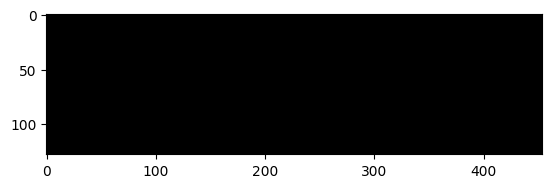

umbral: 42



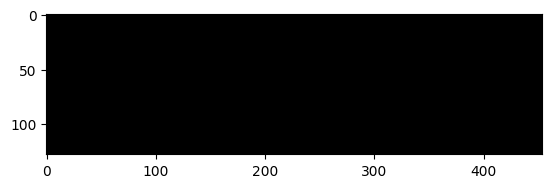

umbral: 43



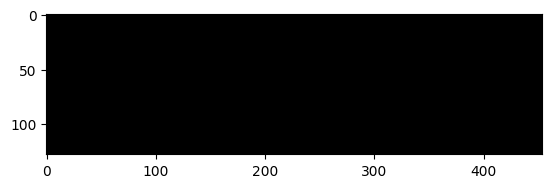

umbral: 44



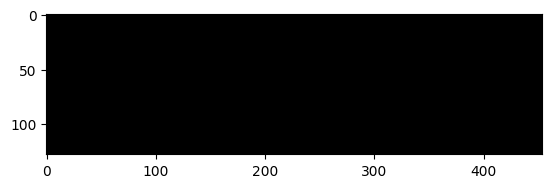

umbral: 45



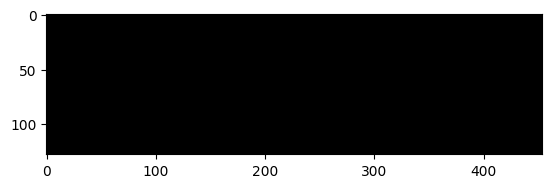

umbral: 46



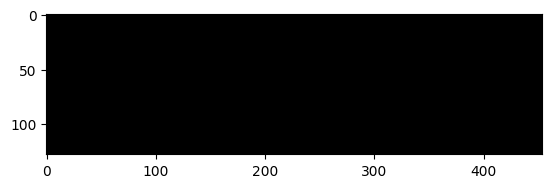

umbral: 47



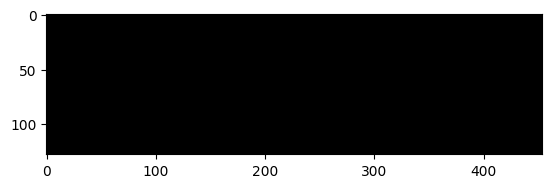

umbral: 48



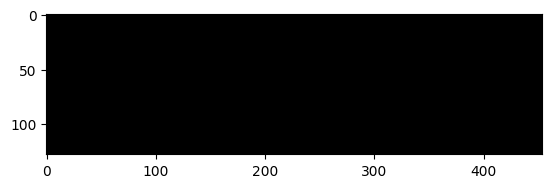

umbral: 49



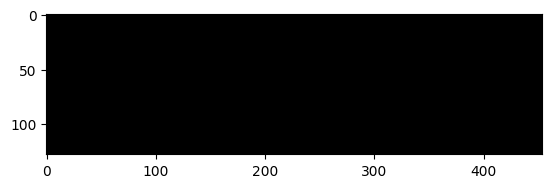

umbral: 50



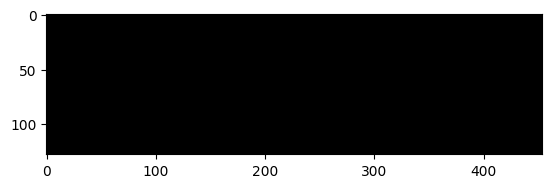

umbral: 51



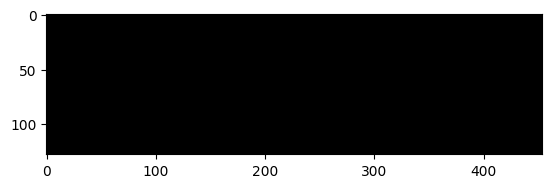

umbral: 52



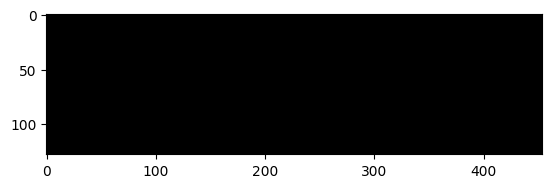

umbral: 53



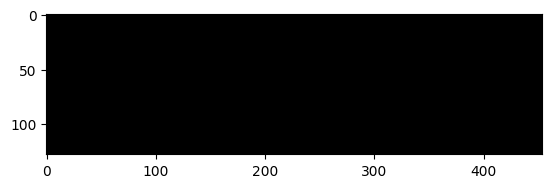

umbral: 54



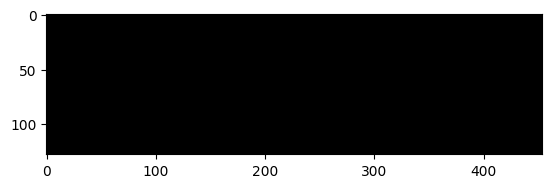

umbral: 55



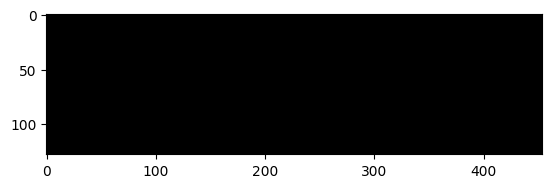

umbral: 56



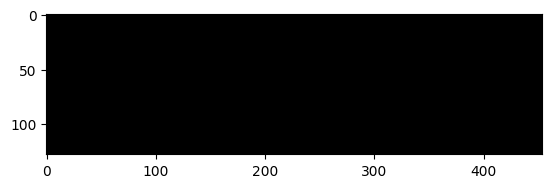

umbral: 57



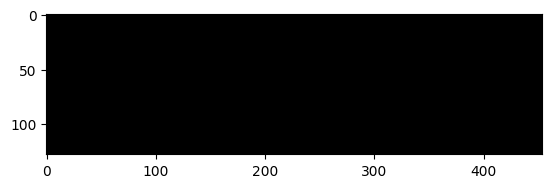

umbral: 58



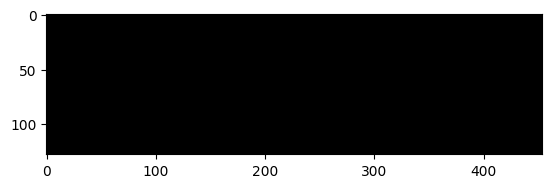

umbral: 59



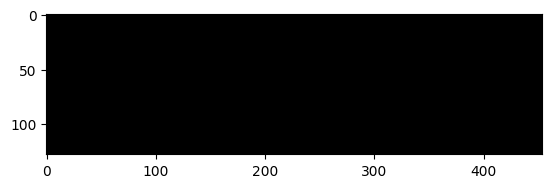

umbral: 60



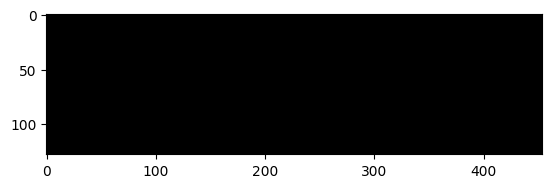

umbral: 61



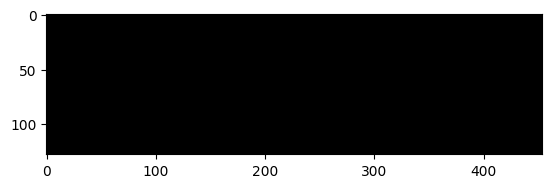

umbral: 62



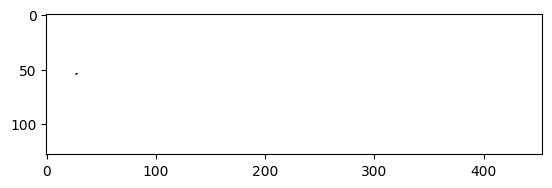

umbral: 63



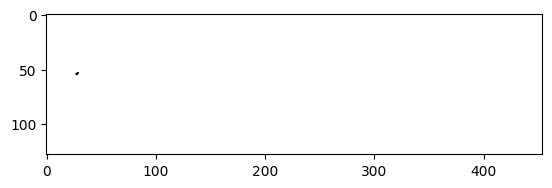

umbral: 64



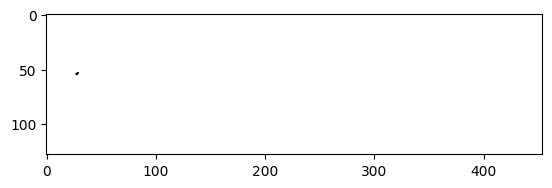

umbral: 65



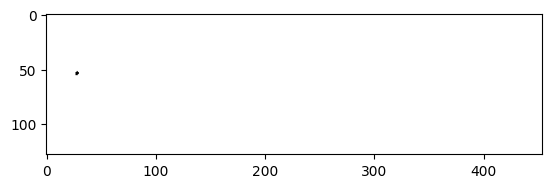

umbral: 66



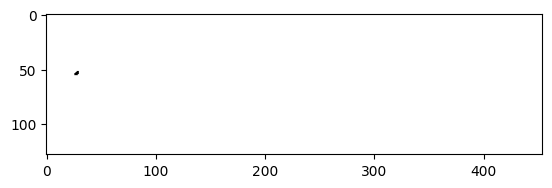

umbral: 67



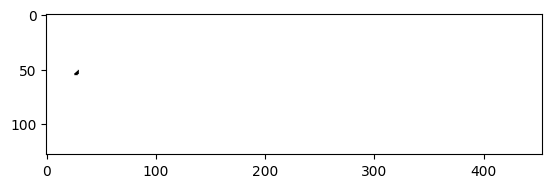

umbral: 68



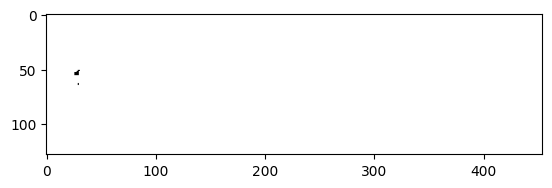

umbral: 69



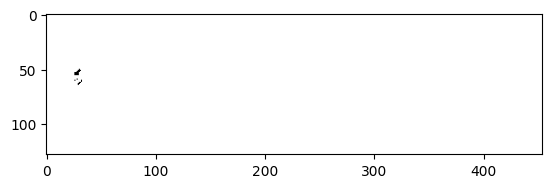

umbral: 70



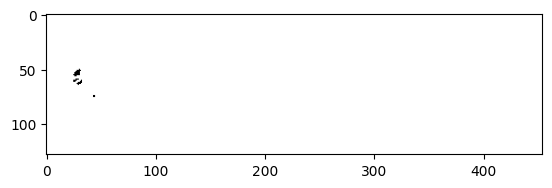

umbral: 71



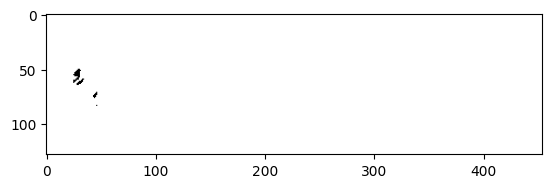

umbral: 72



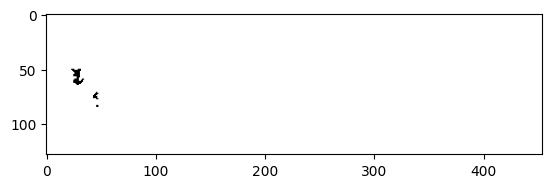

umbral: 73



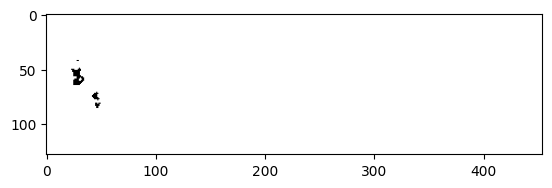

umbral: 74
a



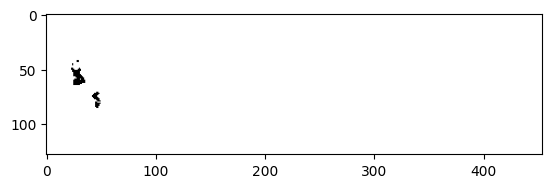

umbral: 75



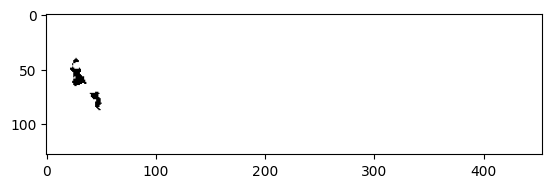

umbral: 76
a



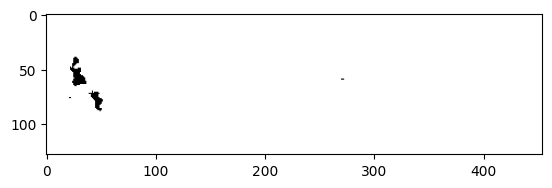

umbral: 77



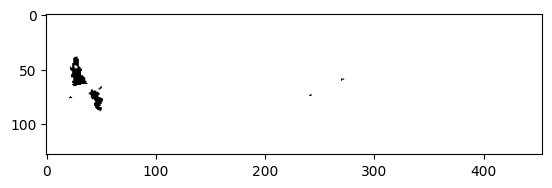

umbral: 78



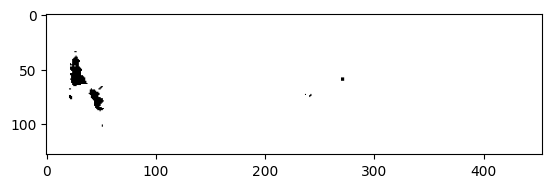

umbral: 79



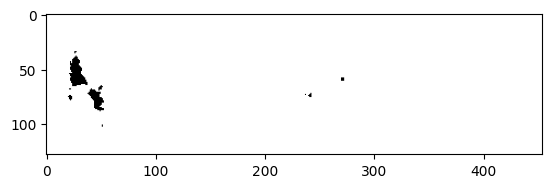

umbral: 80



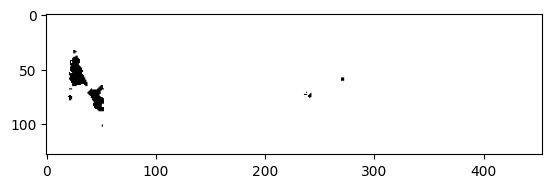

umbral: 81



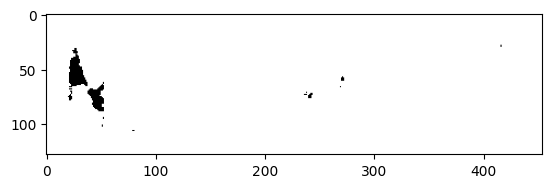

umbral: 82



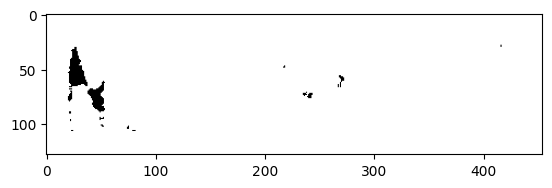

umbral: 83



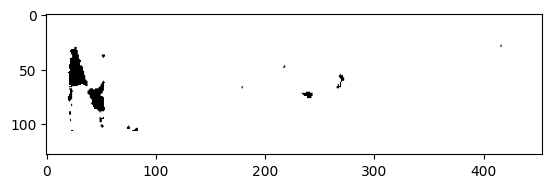

umbral: 84



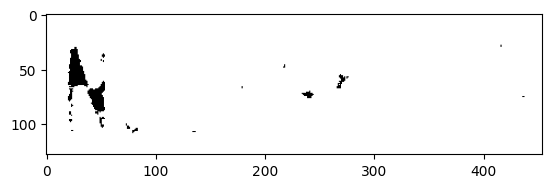

umbral: 85



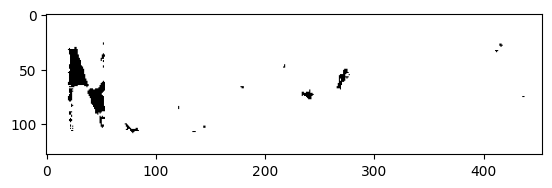

umbral: 86



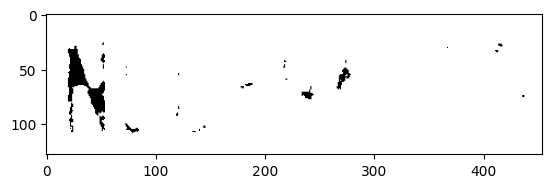

umbral: 87



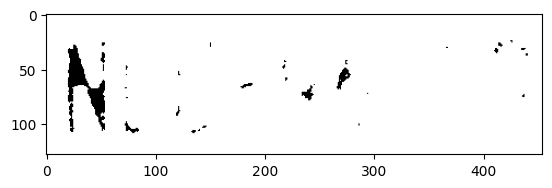

umbral: 88



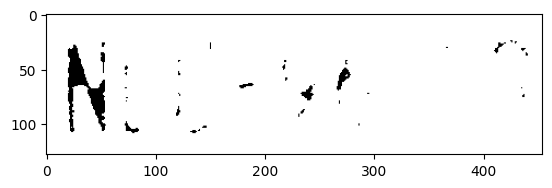

umbral: 89



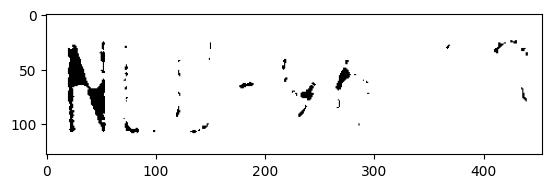

umbral: 90



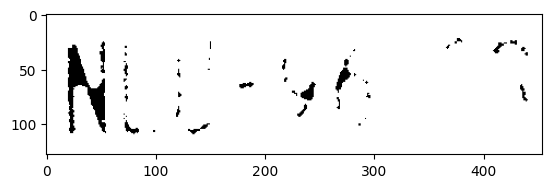

umbral: 91



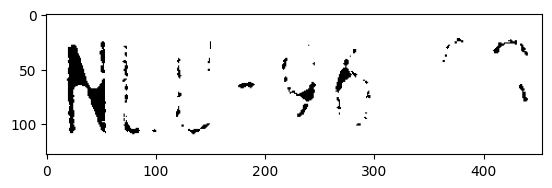

umbral: 92



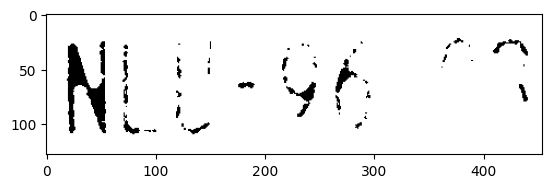

umbral: 93



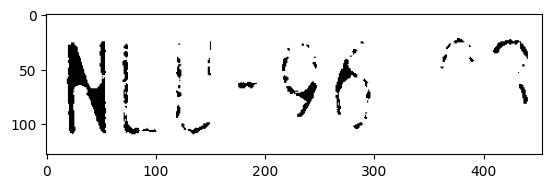

umbral: 94



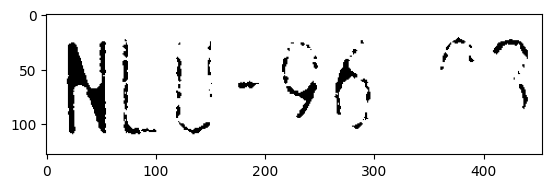

umbral: 95
1
_———



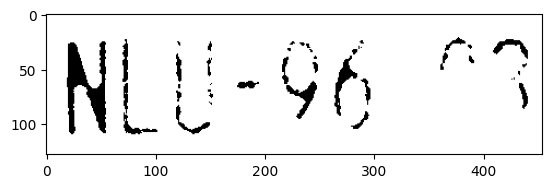

umbral: 96



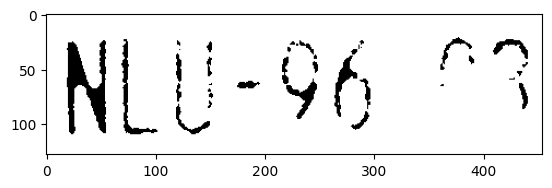

umbral: 97



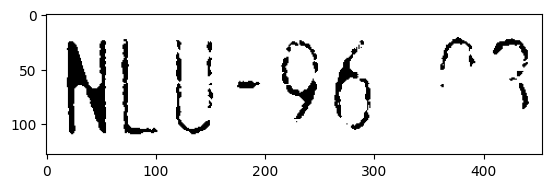

umbral: 98



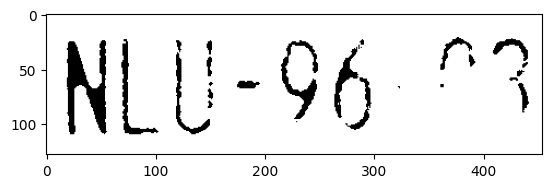

umbral: 99
NLU=96 3



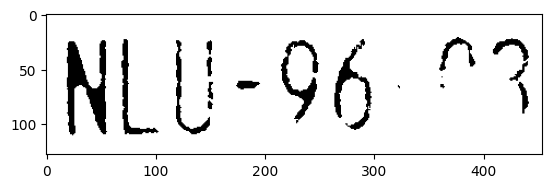

umbral: 100



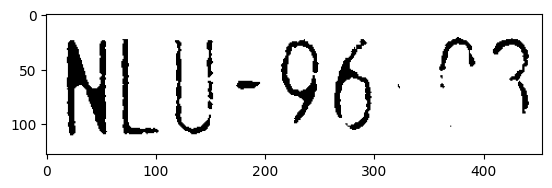

umbral: 101
NEU=95 3



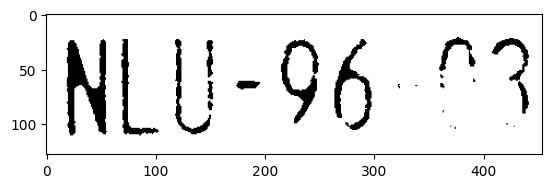

umbral: 102
NEU=96 3



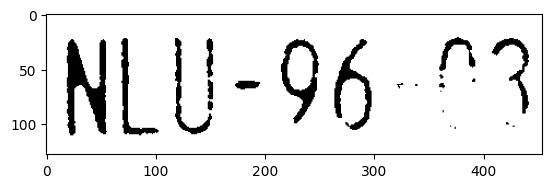

umbral: 103



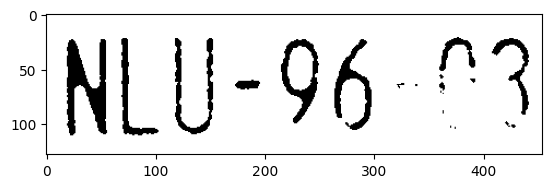

umbral: 104
NLU -96- "3



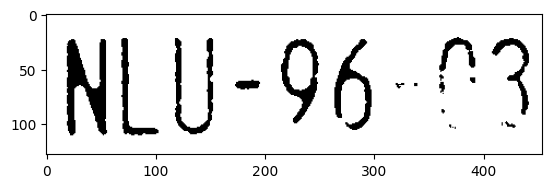

umbral: 105
NLU-96-"3



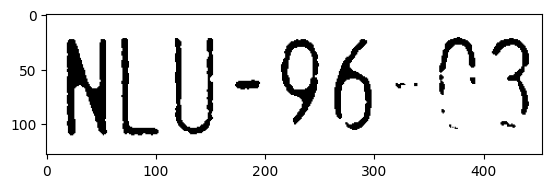

umbral: 106
NLU-96-"3



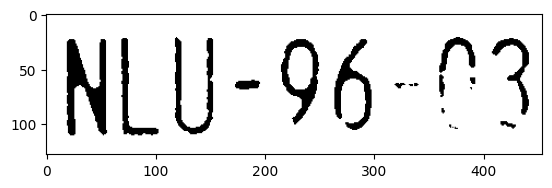

umbral: 107
NLU-96-"3



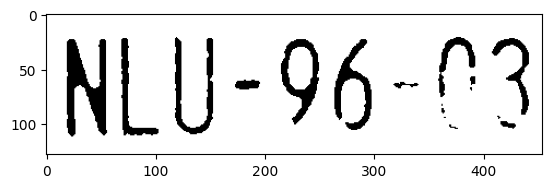

umbral: 108
NLU-96-"3



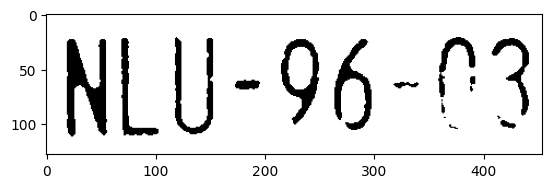

umbral: 109
NLU-96-"3



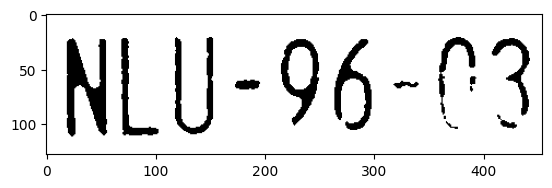

umbral: 110
NLU-96-173



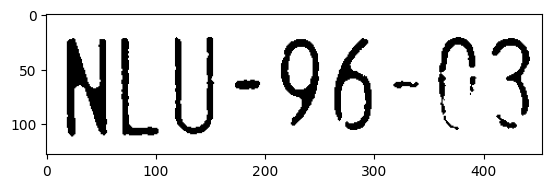

umbral: 111
NLU-96-03



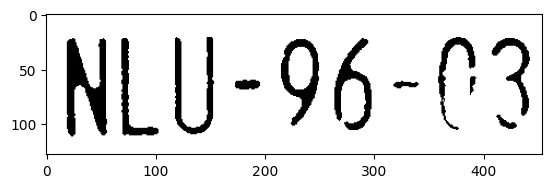

umbral: 112
NLU-96-13



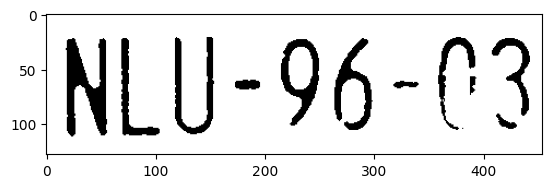

umbral: 113
NLU-96-03



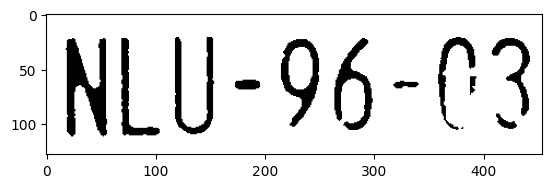

umbral: 114
NLU-96-03



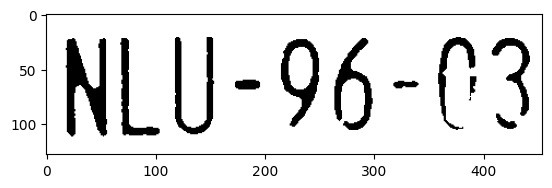

umbral: 115
NLU-96-03



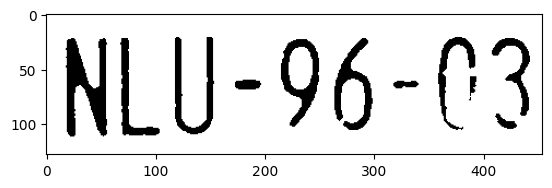

umbral: 116
NLU-96-03



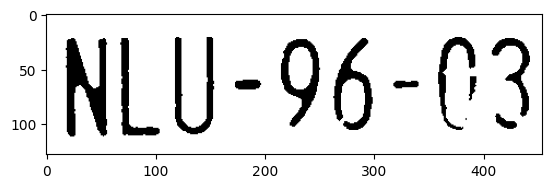

umbral: 117
NLU-96-03



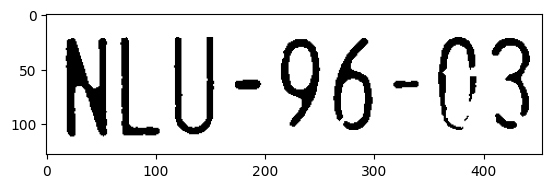

umbral: 118
NLU-96-03



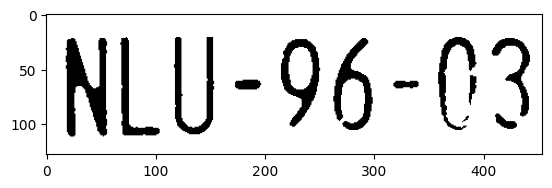

umbral: 119
NLU-96-03



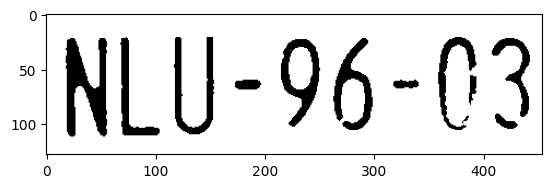

umbral: 120
NLU-96-03



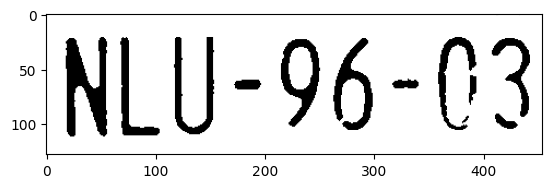

umbral: 121
NLU-96-03



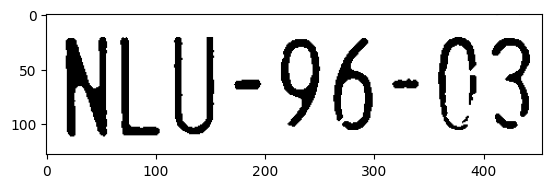

umbral: 122
NLU-96-03



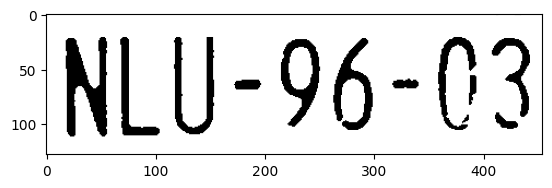

umbral: 123
NLU-96-03



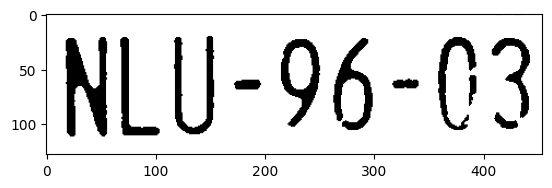

umbral: 124
NLU-96-03



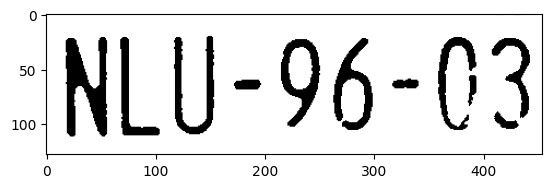

umbral: 125
NLU-96-03



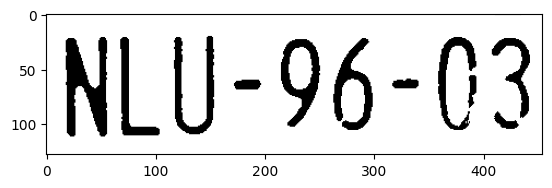

umbral: 126
NLU-96-023



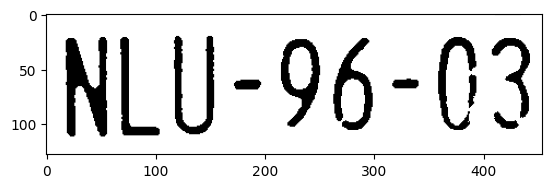

umbral: 127
NLU-96-03



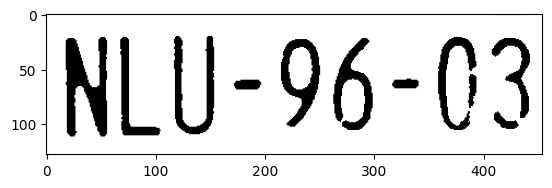

umbral: 128
NLU-96-03



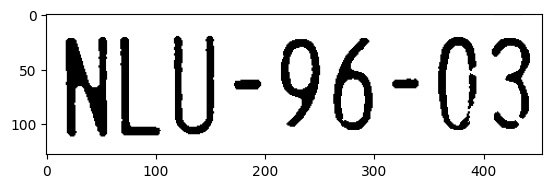

umbral: 129
NLU-96-03



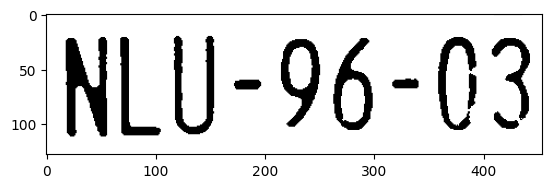

umbral: 130
NLU-96-03



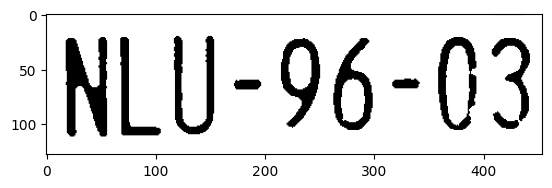

umbral: 131
NLU-96-03



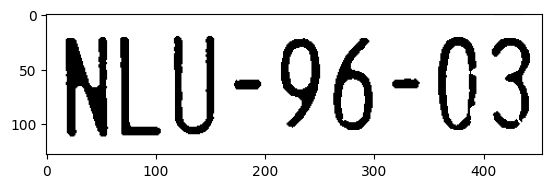

umbral: 132
NLU-96-03



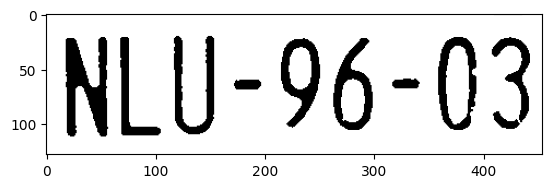

umbral: 133
NLU-96-03



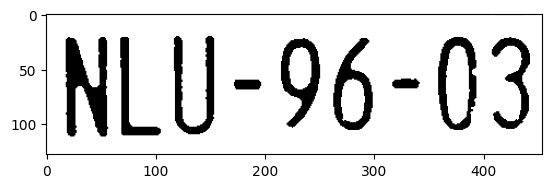

umbral: 134
NLU-96-03



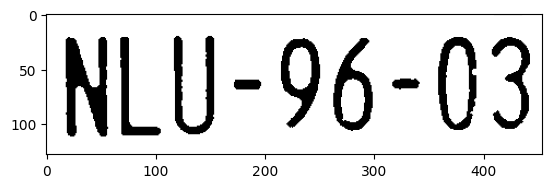

umbral: 135
NLU-96-03



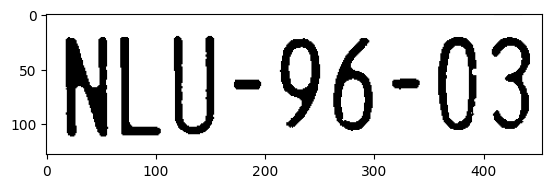

umbral: 136
NLU-96-03



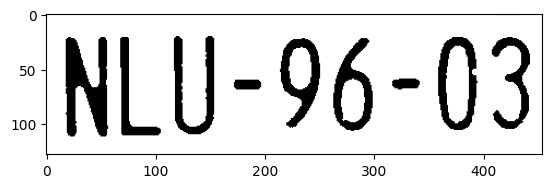

umbral: 137
NL -96-03



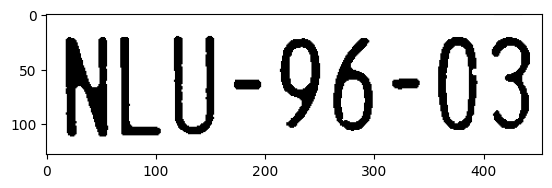

umbral: 138
Ni -96-03



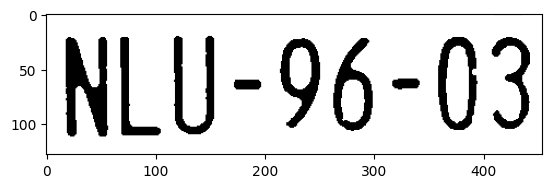

umbral: 139
Ni -96-03



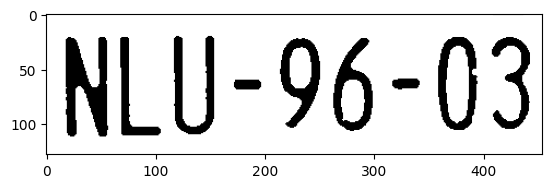

umbral: 140
Ni -96-03



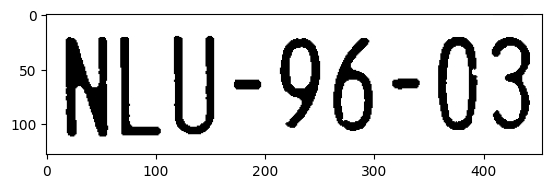

umbral: 141
Ni -96-03



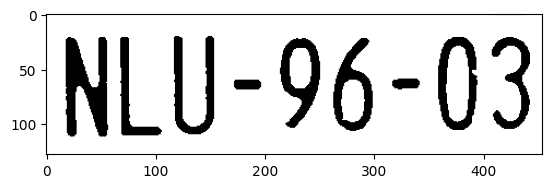

umbral: 142
Ni -96-03



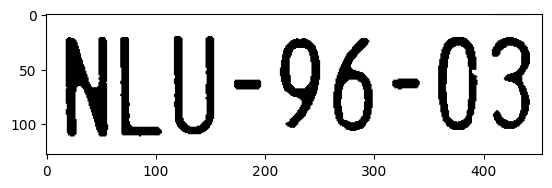

umbral: 143
NI Y-96-03



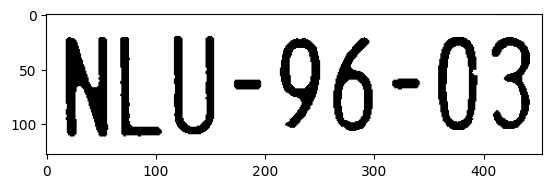

umbral: 144
NL W-96-03



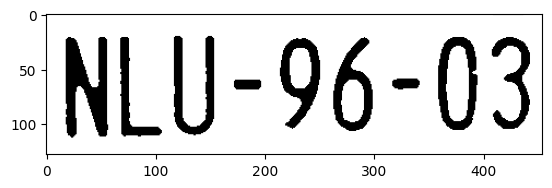

umbral: 145
NLU-96-3



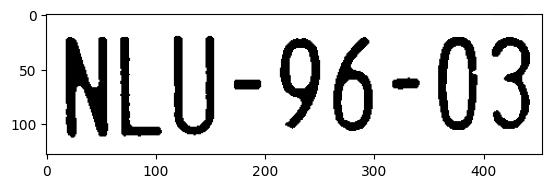

umbral: 146
NLU-96-03



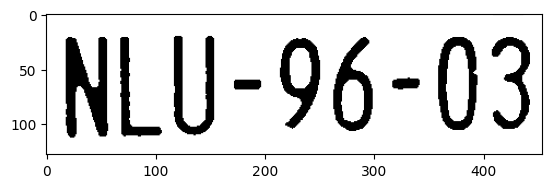

umbral: 147
NLU-96-03



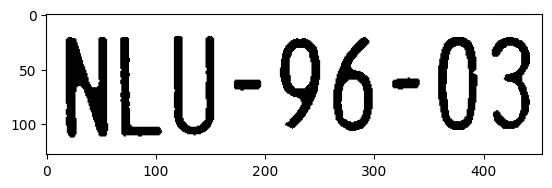

umbral: 148
NLU-96-03



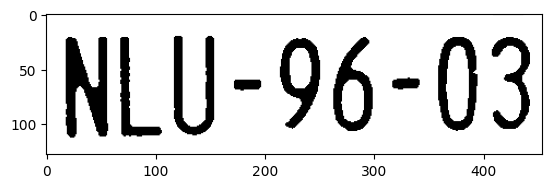

umbral: 149
NLU-96-3



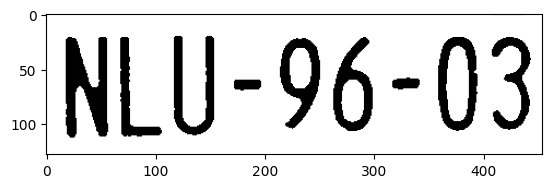

umbral: 150
NLU-96-03



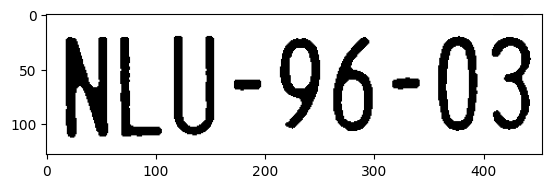

umbral: 151
NLU-96-03



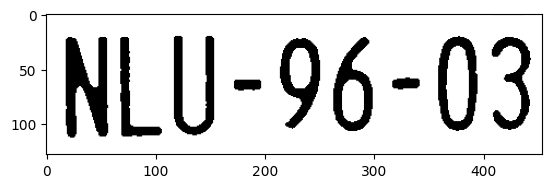

umbral: 152
NLU-96-03



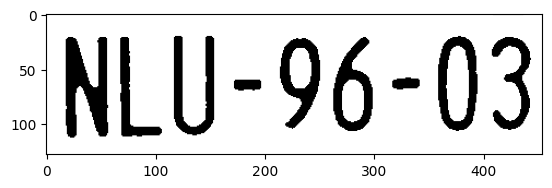

umbral: 153
NLU-96-03



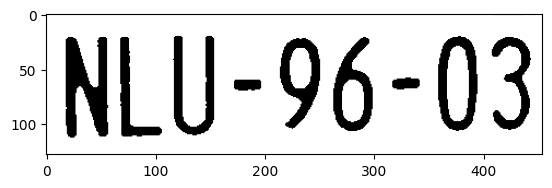

umbral: 154
NLU-96-03



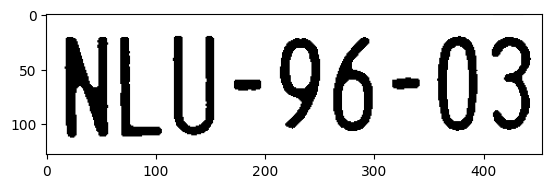

umbral: 155
Ni U-96-03



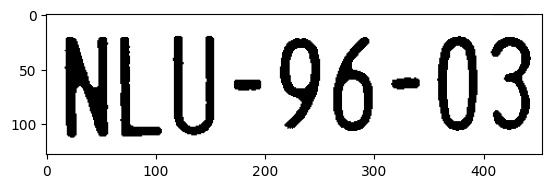

umbral: 156
Ni U-96-03



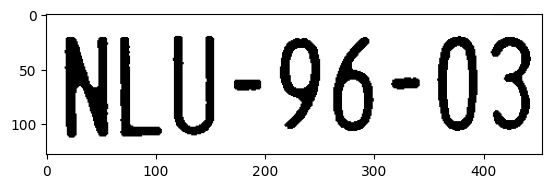

umbral: 157
NI U-96-03



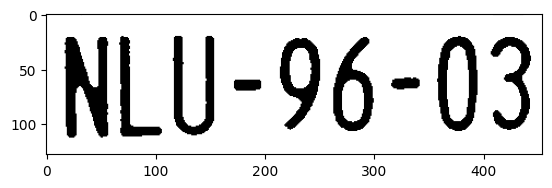

umbral: 158
NLU-96-03



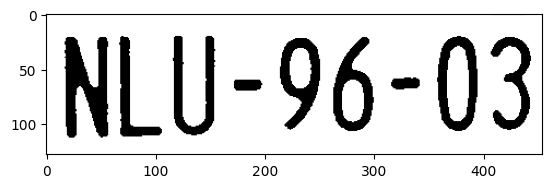

umbral: 159
NLU-96-03



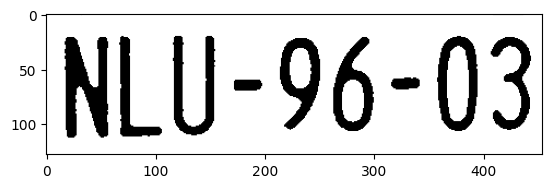

umbral: 160
NLU-96-03



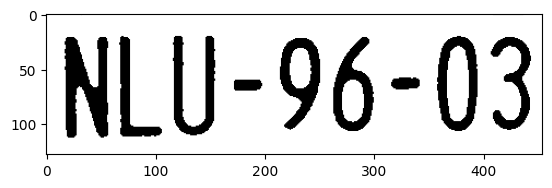

umbral: 161
NLU-96-03



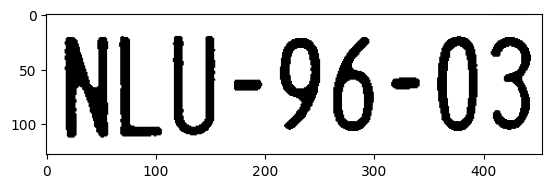

umbral: 162
NLU-96-03



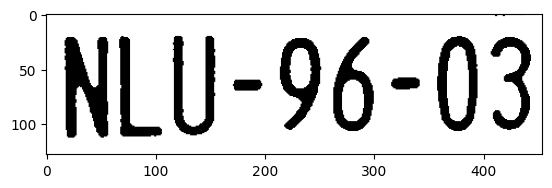

umbral: 163
NLU=96-03



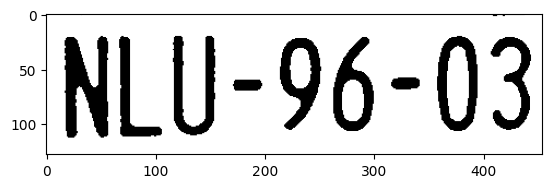

umbral: 164
NLU=96-03



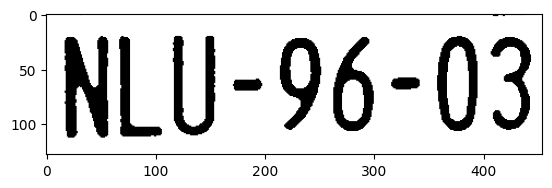

umbral: 165
NLU=96-03



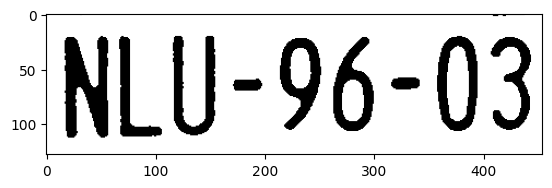

umbral: 166
NLU=96-03



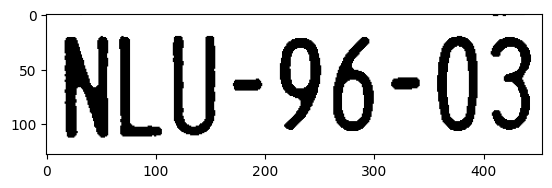

umbral: 167
NLU=96-03



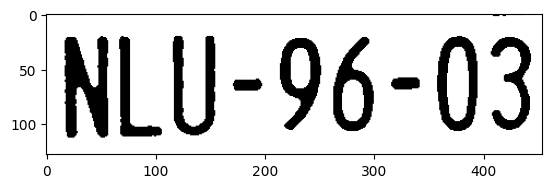

umbral: 168
NLU=96-03



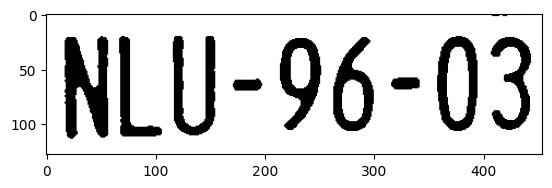

umbral: 169
NLU-96-03



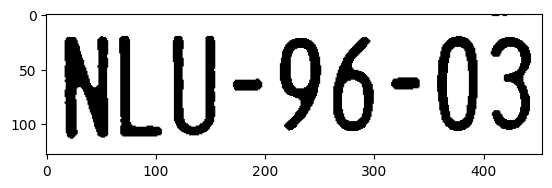

umbral: 170
NLU-96-03



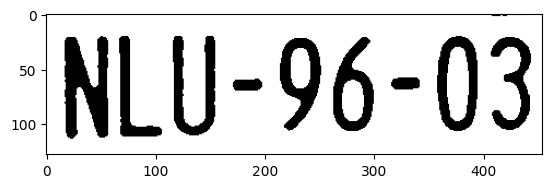

umbral: 171
NLU-96-03



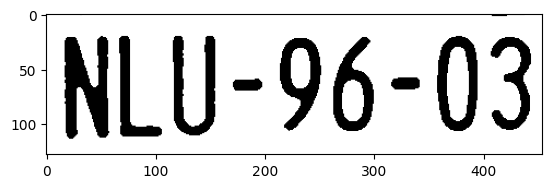

umbral: 172
NLU-96-03



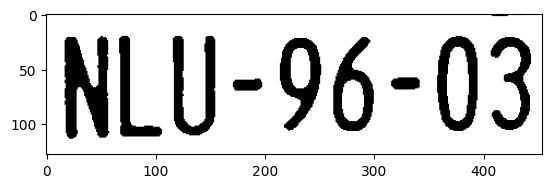

umbral: 173
NLU-96-03



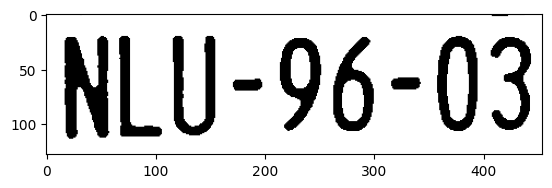

umbral: 174
NLU-96-03



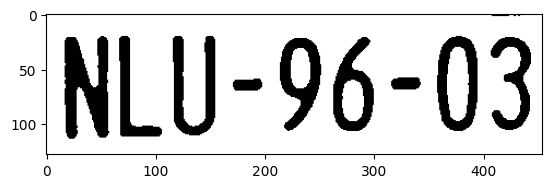

umbral: 175
NLU-96-03



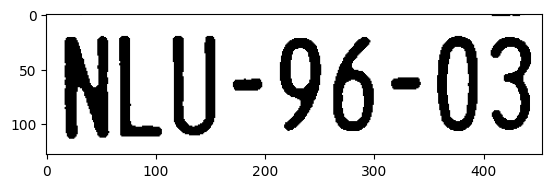

umbral: 176
ALU-96-03



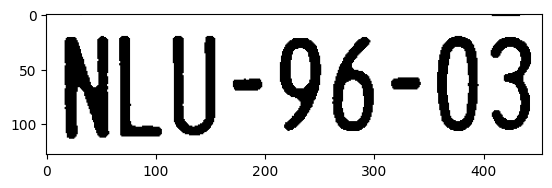

umbral: 177
NLU-96-03



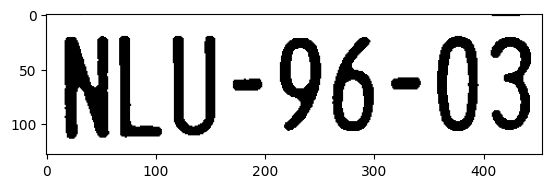

umbral: 178
NLU-96-03



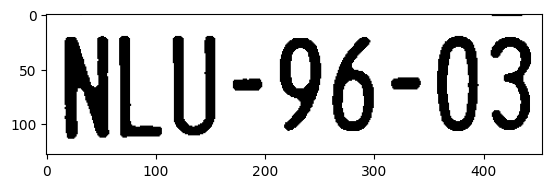

umbral: 179
NLU-96-03



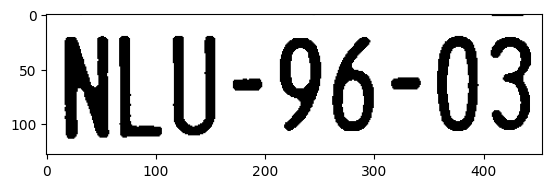

umbral: 180
NLU-96-03



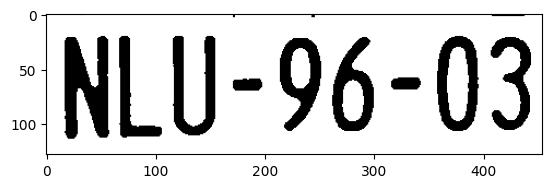

umbral: 181
NLU-96-03



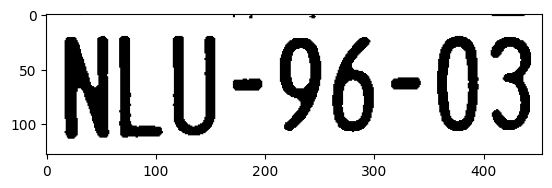

umbral: 182
NLU-96-03



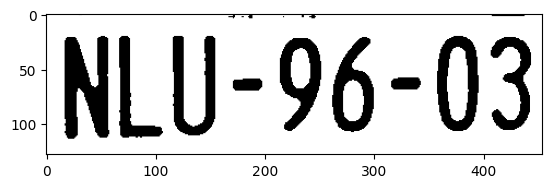

umbral: 183
NLU-96-03



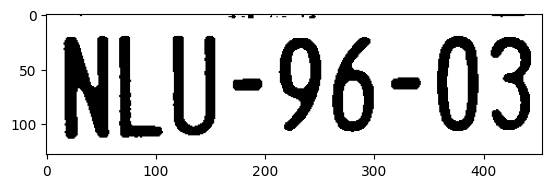

umbral: 184
NLU-96-03



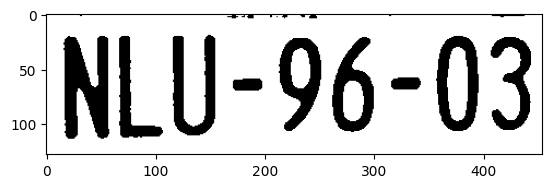

umbral: 185
NLU-96-03



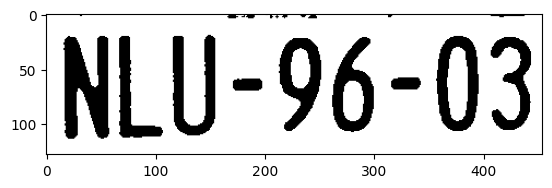

umbral: 186
NLU-96-03



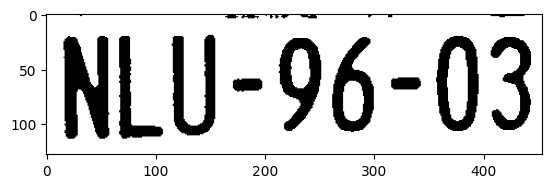

umbral: 187
NLU-96-03



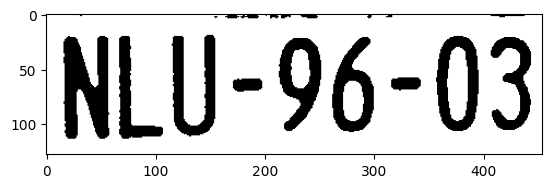

umbral: 188
NLU-96-03



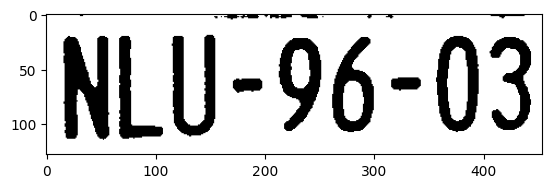

umbral: 189



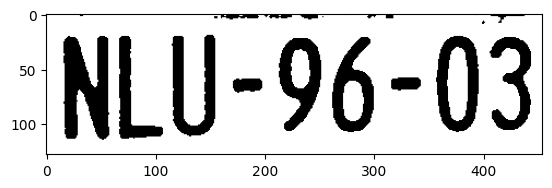

umbral: 190



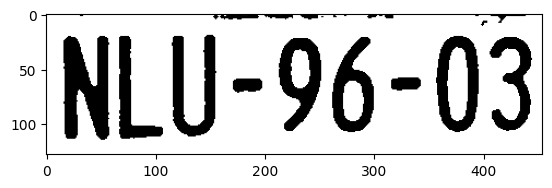

umbral: 191



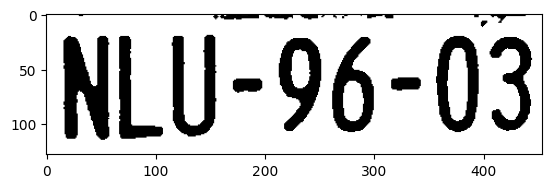

umbral: 192



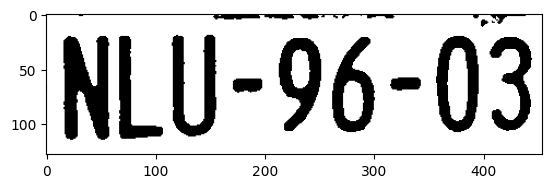

umbral: 193



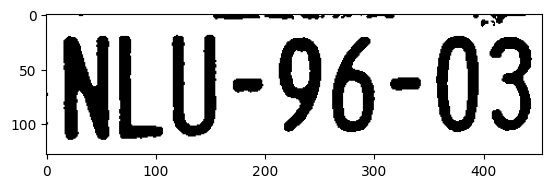

umbral: 194



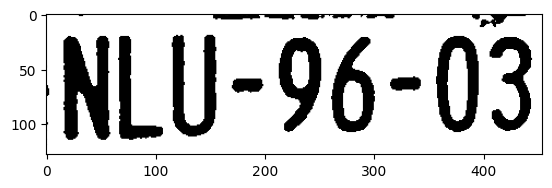

umbral: 195



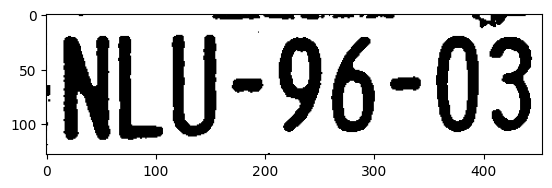

umbral: 196



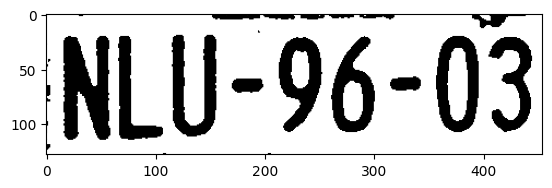

umbral: 197



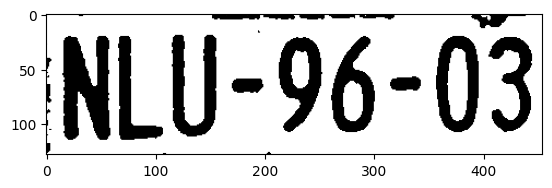

umbral: 198



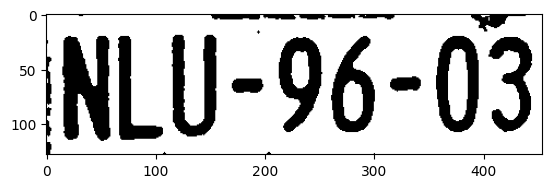

umbral: 199



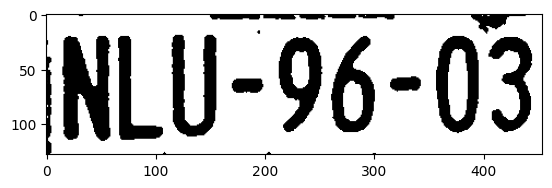

umbral: 200



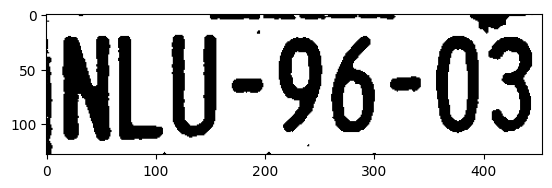

umbral: 201



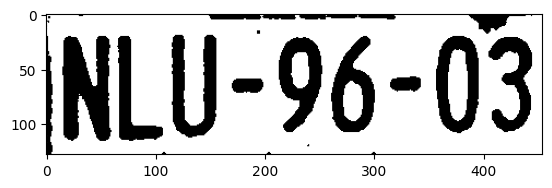

umbral: 202



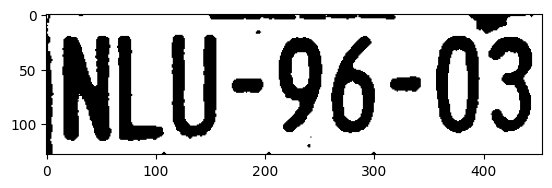

umbral: 203



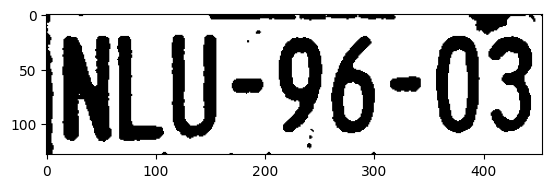

umbral: 204
NLU-96-03



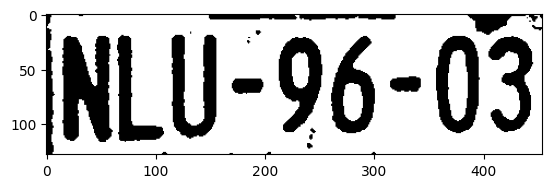

umbral: 205



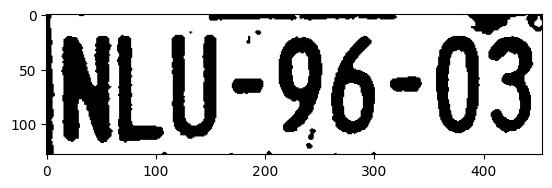

umbral: 206



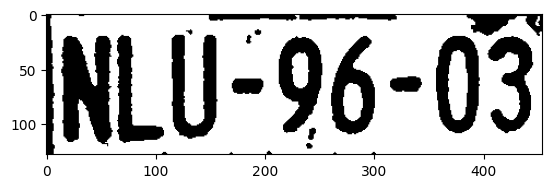

umbral: 207



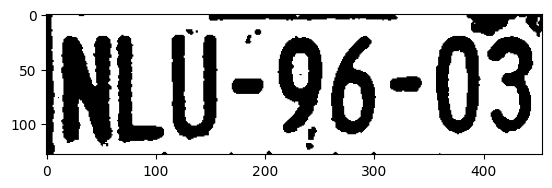

umbral: 208



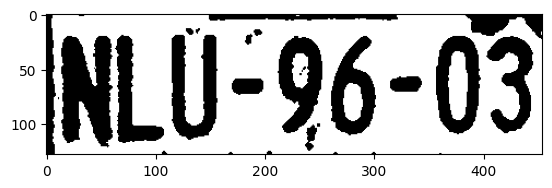

umbral: 209



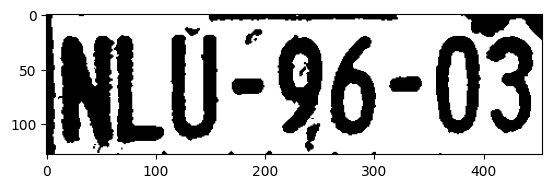

umbral: 210



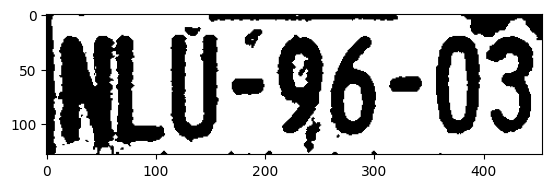

umbral: 211



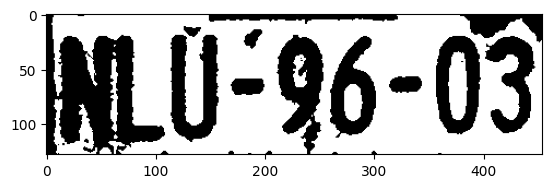

umbral: 212



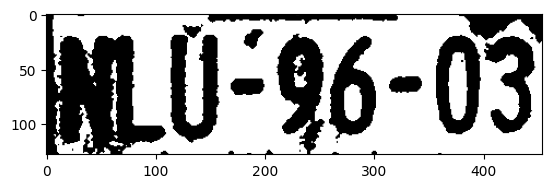

KeyboardInterrupt: 

In [78]:
# Probando todos los umbrales
for umbral in range(256):
  h, placaBin = cv2.threshold(placaFiltrada, umbral, 1,
                              cv2.THRESH_BINARY)
  plt.imshow(placaBin, cmap='gray')
  plt.show()
  textoBin = pytesseract.image_to_string(placaBin)
  print('umbral:', umbral)
  print(textoBin)